<a href="https://colab.research.google.com/github/WellBrian/FUTURE_DS_03/blob/main/Student_satisfaction_survey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import necessary libraries

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

Mounted at /content/drive


Load the file

In [11]:
file_path = "/content/Student_Satisfaction_Survey.csv"

df = pd.read_csv(file_path, encoding='latin1', index_col='SN')
df.head()

,Total Feedback Given,Total Configured,Questions,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5,Average/ Percentage,Course Name,Basic Course
SN,,,,,,,,,,,
1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
4,1,12,The teachers approach to teaching can best be...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,4.00 / 80.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 580 entries, 1 to 20
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Total Feedback Given  580 non-null    int64 
 1   Total Configured      580 non-null    int64 
 2   Questions             580 non-null    object
 3   Weightage 1           580 non-null    int64 
 4   Weightage 2           580 non-null    int64 
 5   Weightage 3           580 non-null    int64 
 6   Weightage 4           580 non-null    int64 
 7   Weightage 5           580 non-null    int64 
 8   Average/ Percentage   580 non-null    object
 9   Course Name           580 non-null    object
 10  Basic Course          580 non-null    object
dtypes: int64(7), object(4)
memory usage: 54.4+ KB


The dataset contains information related to a survey conducted at an autonomous college to evaluate faculty performance. Here's a breakdown of the features in the dataset:

SN: Likely a serial number or identifier for each entry in the survey.  

Total Feedback Given: The number of feedback entries provided by students for a specific question.  

Total Configured: Possibly refers to the total number of students or responses expected for each question.  

Questions: The actual question asked in the survey, related to the performance and effectiveness of faculty members.  

Weightage 1 to Weightage 5: These fields could represent responses or ratings given to each question, possibly on a scale (like 1-5), or categories of answers.  

Average/ Percentage: This could be the average score or percentage calculated from the responses, providing a quantitative measure of the feedback for each question.  

Course Name: The specific course to which the feedback applies.  

Basic Course: A more general category or type of course under which the specific course falls.  

### **Descriptive Statistics**

In [12]:
df["Average"] = df["Average/ Percentage"].str.split("/").str[0].astype(float)
df['Average'].describe()

,Average
count,580.000000
mean,3.842793
std,0.629038
min,1.330000
25%,3.500000
50%,3.920000
75%,4.250000
max,5.000000


Here are the basic statistics for the average scores provided in the feedback:

Count: 580 responses

Mean (Average): 3.84

Standard Deviation: 0.63, indicating the variability of scores around the mean

Minimum Score: 1.33

25th Percentile: 3.50 (indicating that 25% of scores are below 3.50)

Median (50th Percentile): 3.92

75th Percentile: 4.25 (75% of scores are below this value)

Maximum Score: 5.00

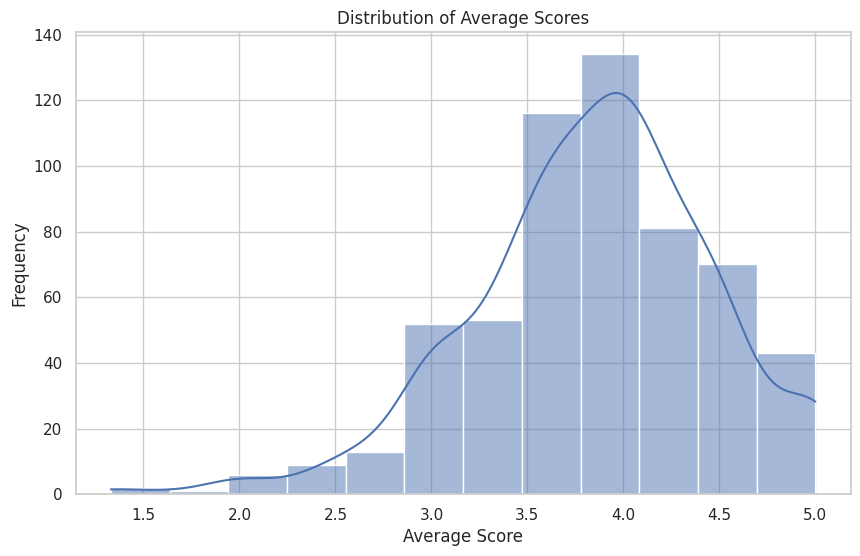

In [16]:
# Setting the style
sns.set(style="whitegrid")

# Creating a histogram for the distribution of average scores
plt.figure(figsize=(10, 6))
sns.histplot(df['Average'], bins=12, kde=True, color="b")
plt.title('Distribution of Average Scores')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.show();

### **Frequency Analysis**

Examining how often each weightage (1 to 5) is assigned across all questions.

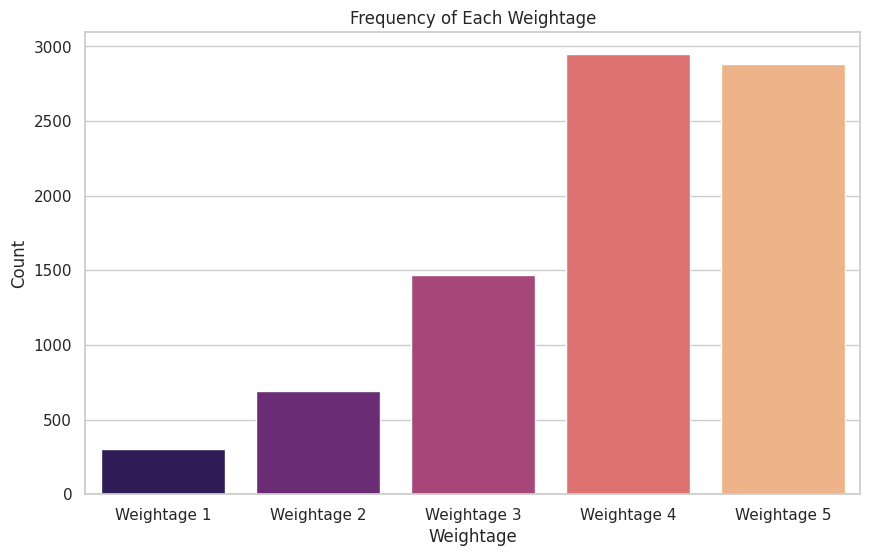

In [20]:
# Preparing the data for frequency analysis of weightages
weightage_columns = ['Weightage 1', 'Weightage 2', 'Weightage 3', 'Weightage 4', 'Weightage 5']
weightage_counts = df[weightage_columns].sum()

# Plotting the frequency of each weightage
plt.figure(figsize=(10, 6))
sns.barplot(x=weightage_counts.index, y=weightage_counts.values, palette="magma")
plt.title('Frequency of Each Weightage')
plt.xlabel('Weightage')
plt.ylabel('Count')
plt.show();

### **Correlation Analysis**

between different weightages

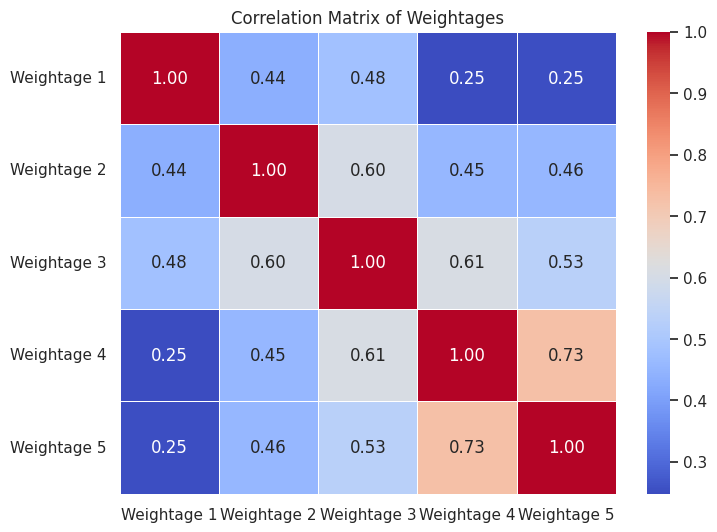

In [21]:
# Calculating the correlation matrix
weightage_correlation = df[weightage_columns].corr()

# Plotting the heatmap for the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(weightage_correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Weightages')
plt.show()

### **Text Analysis on Questions**

Categorizing the questions based on common themes and then analyze the distribution of scores for each theme. First, I need to categorize the questions. Let's take a look at the unique questions to determine potential categories.

In [23]:
# Displaying unique questions to understand potential themes
df['Questions'].unique()

array(['How much of the syllabus was covered in the class?',
       'How well did the teachers prepare for the classes?',
       'How well were the teachers able to communicate?',
       'The teacher\x92s approach to teaching can best be described as',
       'Fairness of the internal evaluation process by the teachers.',
       'Was your performance in assignments discussed with you?',
       'The institute takes an active interest in promoting internships, student exchange, field visit opportunities for students.',
       'The teaching and mentoring process in your institution facilitates you in cognitive, social and\nemotional growth.',
       'The institution provides multiple opportunities to learn and grow.',
       'Teachers inform you about your expected competencies, course outcomes and program\noutcomes.',
       'Your mentor does a necessary follow-up with an assigned task to you.',
       'The teachers illustrate the concepts through examples and applications.',
       'The

In [25]:
# Mapping questions to themes based on the analysis of their content
themes_mapping = {
    'Syllabus Coverage and Preparation': ['How much of the syllabus was covered in the class?',
                                          'How well did the teachers prepare for the classes?'],
    'Communication and Methodology': ['How well were the teachers able to communicate?',
                                     'The teacher\x92s approach to teaching can best be described as',
                                     'The teachers illustrate the concepts through examples and applications.',
                                     'The institute/ teachers use student-centric methods, such as experiential learning, participative learning and problem-solving methodologies for enhancing learning experiences.',
                                     'What percentage of teachers use ICT tools such as LCD projectors, Multimedia, etc. while teaching?'],
    'Assessment and Feedback': ['Fairness of the internal evaluation process by the teachers.',
                                'Was your performance in assignments discussed with you?',
                                'Your mentor does a necessary follow-up with an assigned task to you.'],
    'Growth and Opportunities': ['The institute takes an active interest in promoting internships, student exchange, field visit opportunities for students.',
                                 'The teaching and mentoring process in your institution facilitates you in cognitive, social and\nemotional growth.',
                                 'The institution provides multiple opportunities to learn and grow.',
                                 'Teachers inform you about your expected competencies, course outcomes and program\noutcomes.'],
    'Teacher Support and Engagement': ['The teachers identify your strengths and encourage you to provide the proper level of challenges.',
                                      'Teachers are able to identify your weaknesses and help you to overcome them.',
                                      'The institution makes effort to engage students in the monitoring, review and continuous quality improvement of the teaching-learning process.',
                                      'Teachers encourage you to participate in extracurricular activities.'],
    'Skills and Employability': ['Efforts are made by the institute/ teachers to inculcate soft skills, life skills and employability skills to make you ready for the world of work.',
                                'The overall quality of the teaching-learning process in your institute is very good.']
}

# Creating a new column for themes
df['Theme'] = pd.NA
for theme, questions in themes_mapping.items():
    df.loc[df['Questions'].isin(questions), 'Theme'] = theme

# Checking if all themes are assigned correctly
df[['Questions', 'Theme']].drop_duplicates().head(20)

,Questions,Theme
SN,,
1,How much of the syllabus was covered in the cl...,Syllabus Coverage and Preparation
2,How well did the teachers prepare for the clas...,Syllabus Coverage and Preparation
3,How well were the teachers able to communicate?,Communication and Methodology
4,The teachers approach to teaching can best be...,Communication and Methodology
5,Fairness of the internal evaluation process by...,Assessment and Feedback
6,Was your performance in assignments discussed ...,Assessment and Feedback
7,The institute takes an active interest in prom...,Growth and Opportunities
8,The teaching and mentoring process in your ins...,Growth and Opportunities
9,The institution provides multiple opportunitie...,Growth and Opportunities


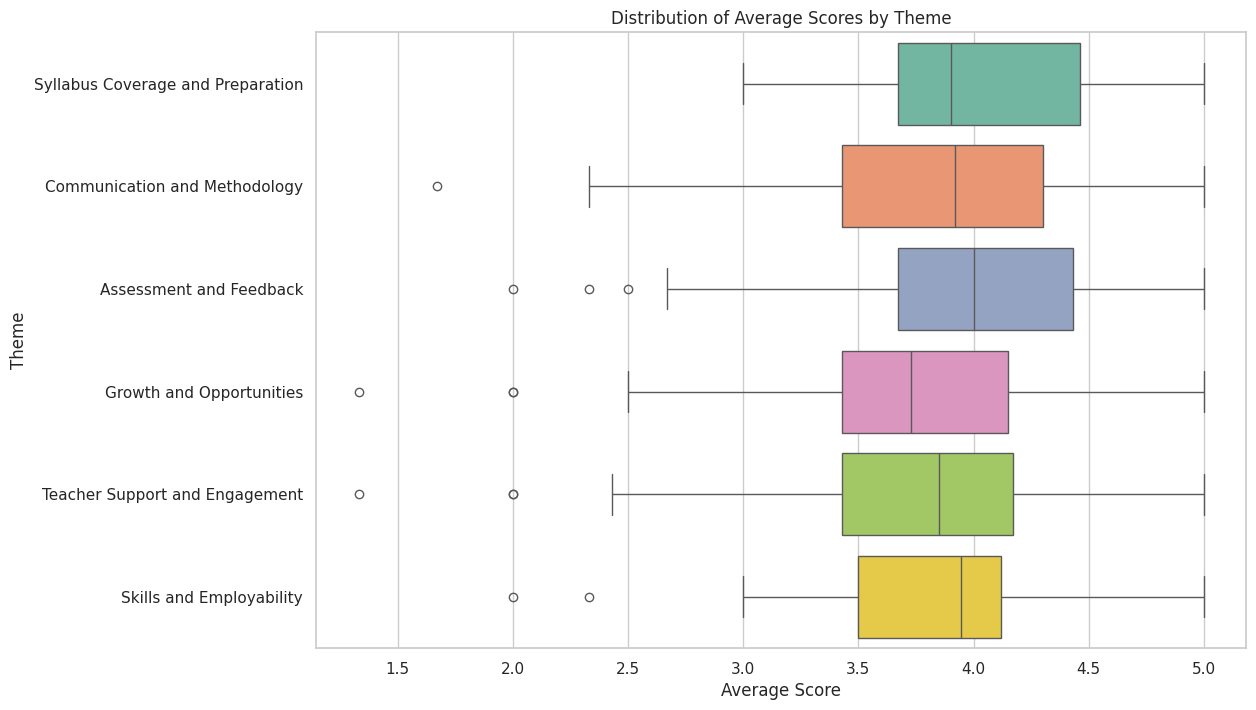

In [26]:
# Plotting
plt.figure(figsize=(12, 8))
sns.boxplot(x='Average', y='Theme', data=df, palette='Set2')
plt.title('Distribution of Average Scores by Theme')
plt.xlabel('Average Score')
plt.ylabel('Theme')
plt.show();